Heart Disease Classification

In [1]:
import pandas as pd

In [37]:
#Regular EDA
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report 
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [38]:
df = pd.read_csv("heart-disease.csv")

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


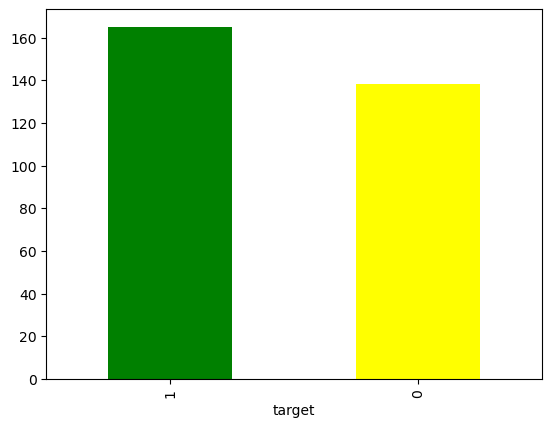

In [8]:
df["target"].value_counts().plot(kind="bar", color=["green", "yellow"])
plt.show()

In [9]:
df["sex"].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [10]:
pd.crosstab(df["sex"], df["target"])

target,0,1
sex,,
0,24,72
1,114,93


In [11]:
pd.crosstab(df["sex"], df["target"]).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])
plt.title("Heart Disease Among Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.legend(["Women", "Men"])

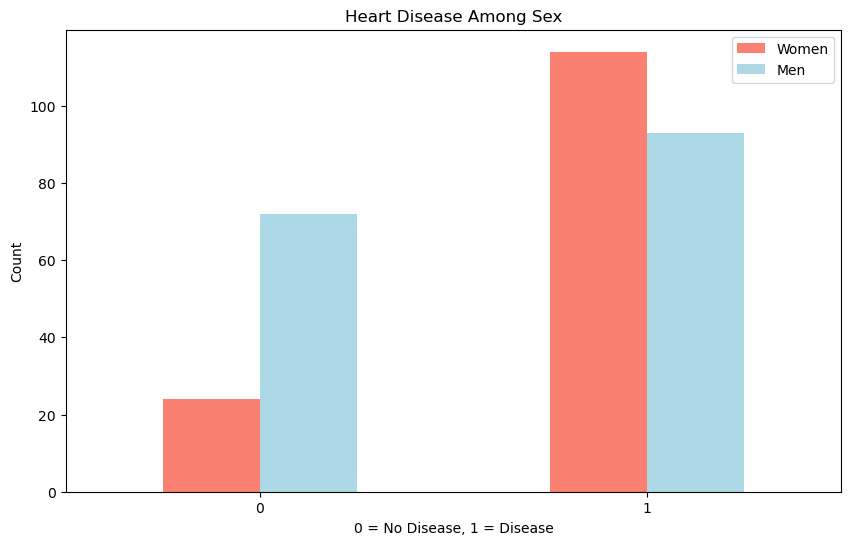

In [12]:
plt.xticks(rotation=0)
plt.show()

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


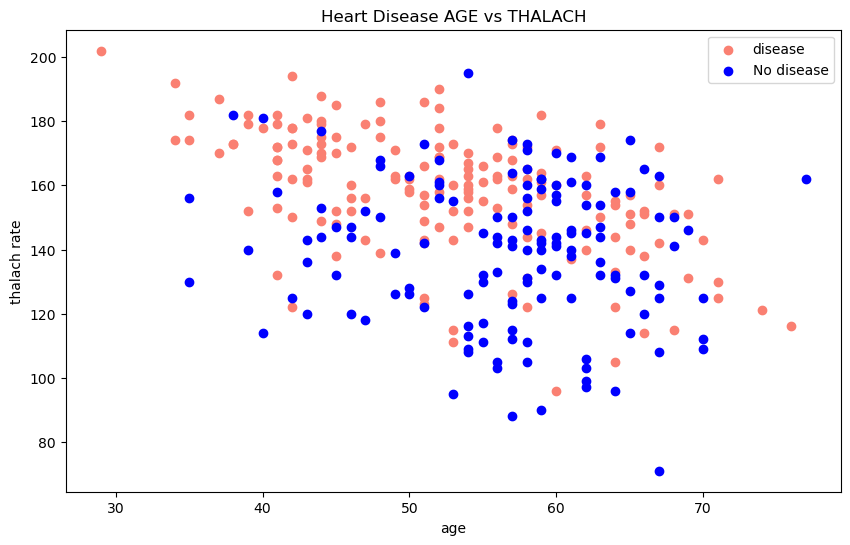

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df[df["target"]==1]["age"], df[df["target"]==1]["thalach"], color=["salmon"])
plt.scatter(df[df["target"]==0]["age"], df[df["target"]==0]["thalach"], color=["blue"])
plt.title("Heart Disease AGE vs THALACH")
plt.xlabel("age")
plt.ylabel("thalach rate")
plt.legend(["disease", "No disease"])
plt.show();

In [15]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [16]:
df["cp"].value_counts()

cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64

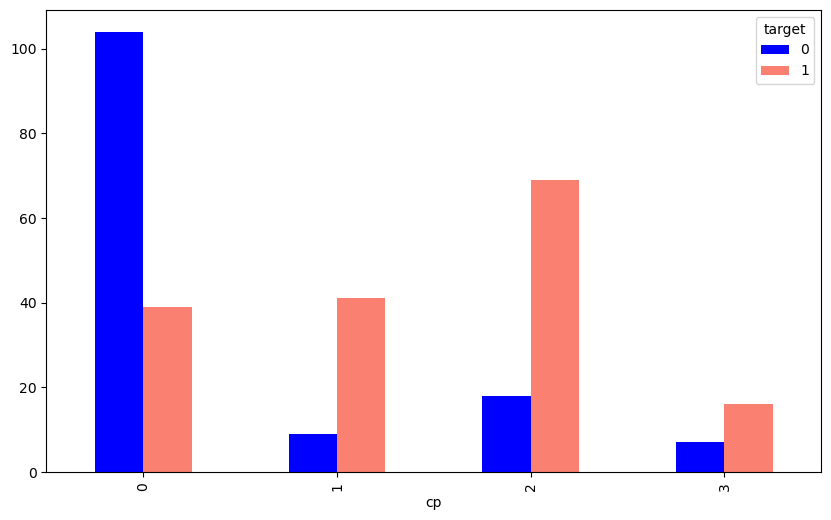

In [17]:
pd.crosstab(df["cp"], df["target"]).plot(kind="bar", figsize=(10,6), color=["blue", "salmon", "brown", "lightblue"])
plt.show();

In [18]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


In [19]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

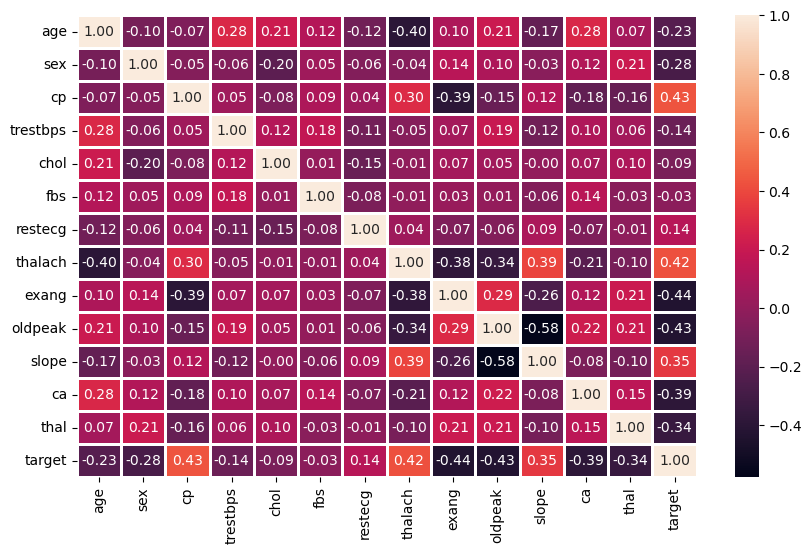

In [20]:
cor_matrix = df.corr()
fig,ax = plt.subplots(figsize=(10,6))
ax = sns.heatmap(cor_matrix, annot=True,linewidths=1,fmt=".2f", cmap="rocket") 
plt.show();

In [21]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## MODELLING

In [22]:
x = df.drop("target",axis=1)
y = df["target"]

In [23]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [24]:
np.random.seed(2)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [25]:
y_train

237    0
106    1
10     1
153    1
77     1
      ..
75     1
22     1
72     1
15     1
168    0
Name: target, Length: 242, dtype: int64

In [26]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
237,60,1,0,140,293,0,0,170,0,1.2,1,2,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
10,54,1,0,140,239,0,1,160,0,1.2,2,0,2
153,66,0,2,146,278,0,0,152,0,0.0,1,1,2
77,59,1,1,140,221,0,1,164,1,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
22,42,1,0,140,226,0,1,178,0,0.0,2,0,2
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
15,50,0,2,120,219,0,1,158,0,1.6,1,0,2


3 models:
1. Logistic Regression
2. K Neighbours
3. RandomForestClassifier

In [58]:
# put models in a dictionary
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

def fit_score(models, x_train, x_test, y_train, y_test):
    np.random.seed(2)
    model_scores = {}
    for name,model in models.items():
        model.fit(x_train,y_train)
        model_scores[name] = model.score(x_test,y_test)
    return model_scores

In [59]:
model_score  = fit_score(models,x_train,x_test,y_train,y_test)

C:\Users\Siddhartha Yarkala\Desktop\Heart-disease\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [84]:
model_score

{'Logistic Regression': 0.9016393442622951,
 'KNN': 0.7049180327868853,
 'Random Forest': 0.9016393442622951}

C:\Users\Siddhartha Yarkala\Desktop\Heart-disease\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


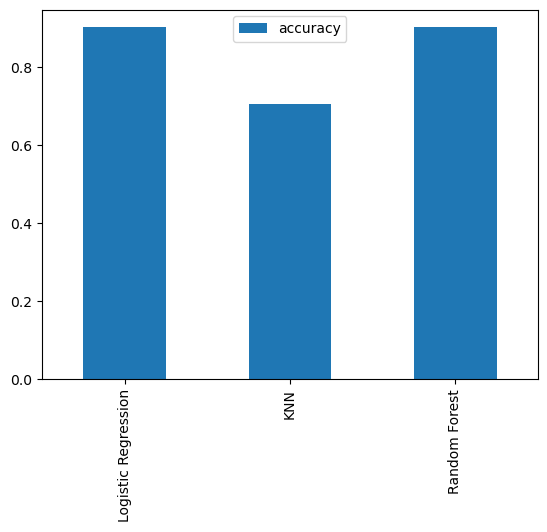

In [60]:
model_compare = pd.DataFrame(fit_score(models,x_train,x_test,y_train,y_test), index=["accuracy"])
model_compare.T.plot.bar();
plt.show()

In [30]:
model_compare_trans = model_compare.T

In [31]:
model_compare_trans

,accuracy
Logistic Regression,0.901639
KNN,0.704918
Random Forest,0.901639


## Hyperparameter tuning

In [44]:
train_scores = []
test_scores = []

neighbors = range(1,21)
knn = KNeighborsClassifier()

for i in neighbors:
    knn.set_params(n_neighbors=i)
    knn.fit(x_train,y_train)
    test_scores.append(knn.score(x_test,y_test))
    train_scores.append(knn.score(x_train,y_train))
    

In [45]:
test_scores

[0.6065573770491803,
 0.639344262295082,
 0.7213114754098361,
 0.7213114754098361,
 0.7049180327868853,
 0.7049180327868853,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6557377049180327,
 0.6557377049180327,
 0.6557377049180327,
 0.6885245901639344,
 0.7049180327868853,
 0.6885245901639344,
 0.7213114754098361,
 0.7540983606557377,
 0.7540983606557377,
 0.7704918032786885]

In [34]:
max(test_scores)

0.7704918032786885

In [52]:
plt.plot(neighbors, test_scores, label="test score", color="Salmon")
plt.plot(neighbors, train_scores, label="train score", color="Blue")
plt.xticks(np.arange(1,21,1))
plt.xlabel("Score")
plt.ylabel("neighbors value")
plt.legend()

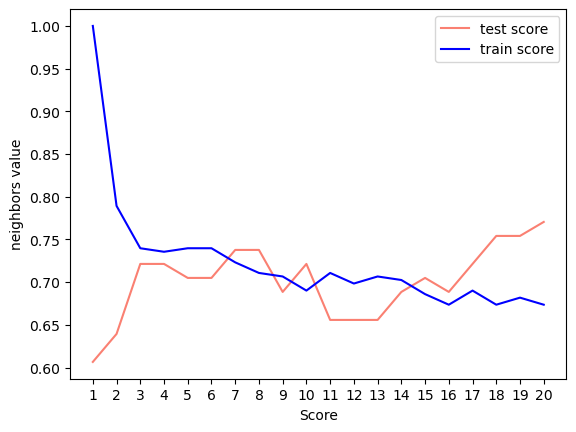

In [53]:
plt.show()

Creating a hyperparameter grid for LogisticRegression

In [179]:
log_reg_grid = {"C": np.logspace(-4,4,40),
                "tol":np.logspace(-6,-2,5),
                "intercept_scaling":(-5,5,11),
                "solver": ["liblinear"]}

rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None,3,5,10],
           "min_samples_split": np.arange(2,20,2),
           "min_samples_leaf": np.arange(1,20,2)}

In [112]:
model_score

{'Logistic Regression': 0.9016393442622951,
 'KNN': 0.7049180327868853,
 'Random Forest': 0.9016393442622951}

In [113]:
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5, 
                                n_iter=20, 
                                verbose=True)

In [114]:
rs_log_reg.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [115]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [116]:
rs_log_reg.score(x_test,y_test)

0.9180327868852459

In [69]:
model_score

{'Logistic Regression': 0.9016393442622951,
 'KNN': 0.7049180327868853,
 'Random Forest': 0.9016393442622951}

In [90]:
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=30,
                           verbose=True)

In [91]:
rs_rf.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,n_iter,30
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [93]:
rs_rf.score(x_test,y_test)

0.8852459016393442

In [94]:
model_score

{'Logistic Regression': 0.9016393442622951,
 'KNN': 0.7049180327868853,
 'Random Forest': 0.9016393442622951}

In [117]:
rs_log_reg.score(x_test, y_test)

0.9180327868852459

In [121]:
y_predict = rs_log_reg.predict(x_test)
y_predict

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1])

In [119]:
y_test

99     1
296    0
89     1
30     1
234    0
      ..
173    0
94     1
161    1
216    0
91     1
Name: target, Length: 61, dtype: int64

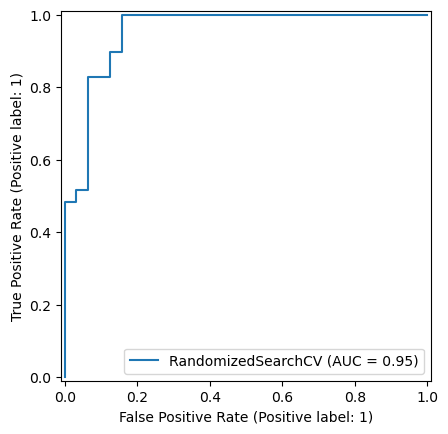

In [130]:

RocCurveDisplay.from_estimator(rs_log_reg, x_test, y_test)
plt.show()

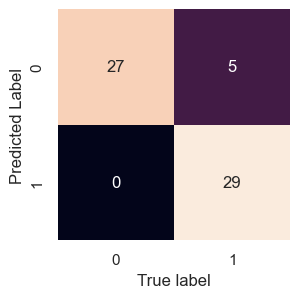

In [143]:
sns.set(font_scale=1.0)
def plot_con_matrix(y_test, y_preds):
    """
    plots the confusion matrix in a nice way
    """
    fig,ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds), annot=True, cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted Label")
    plt.show()

plot_con_matrix(y_test, y_predict)

In [145]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      0.84      0.92        32
           1       0.85      1.00      0.92        29

    accuracy                           0.92        61
   macro avg       0.93      0.92      0.92        61
weighted avg       0.93      0.92      0.92        61



In [180]:
gs_log_reg = GridSearchCV(LogisticRegression(), param_grid=log_reg_grid, cv=5, verbose=True)

In [181]:
gs_log_reg.fit(x_train,y_train)

Fitting 5 folds for each of 600 candidates, totalling 3000 fits


C:\Users\Siddhartha Yarkala\Desktop\Heart-disease\env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1000 fits failed out of a total of 3000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1000 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Siddhartha Yarkala\Desktop\Heart-disease\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Siddhartha Yarkala\Desktop\Heart-disease\env\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:

,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'intercept_scaling': (-5, ...), 'solver': ['liblinear'], 'tol': array([1.e-06...e-03, 1.e-02])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [182]:
gs_log_reg.score(x_test,y_test)

0.9180327868852459

In [178]:
gs_log_reg.best_params_

{'C': np.float64(0.30702906297578497),
 'solver': 'liblinear',
 'tol': np.float64(1e-06)}

In [175]:
rs_log_reg.score(x_test,y_test)

0.9180327868852459

In [176]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [188]:
clf = LogisticRegression(solver='liblinear', C=np.float64(0.23357214690901212))

In [196]:
cv_acc = cross_val_score(clf, x, y, cv=5, scoring="accuracy")
cv_prec = cross_val_score(clf, x, y, cv=5, scoring="precision")
cv_f1 = cross_val_score(clf, x, y, cv=5, scoring="f1")
cv_recall = cross_val_score(clf, x, y, cv=5, scoring="recall")
cv_acc = np.mean(cv_acc)
cv_f1 = np.mean(cv_f1)
cv_recall = np.mean(cv_recall)
cv_prec = np.mean(cv_prec)


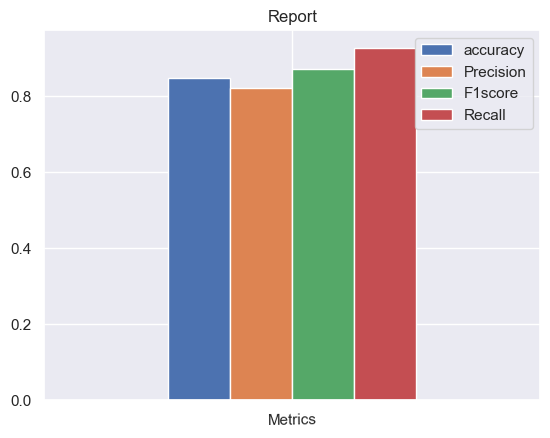

In [223]:
report = pd.DataFrame({"accuracy":cv_acc, "Precision":cv_prec, "F1score":cv_f1, "Recall":cv_recall}, index=["Metrics"])
report.plot.bar(title="Report", legend=["acc", "Prec", "F1", "Recall"])
plt.xticks(rotation=1)
plt.legend()
plt.show()

# Feature Importance

In [225]:
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0....7214690901212)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [226]:
clf.coef_

array([[ 0.00934445, -0.97785889,  0.70381048, -0.01330806, -0.00310596,
        -0.04704672,  0.34835394,  0.02484851, -0.50829556, -0.40765951,
         0.45053223, -0.58411257, -0.5873726 ]])

IndexError: index 1 is out of bounds for axis 0 with size 1

In [229]:
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))

In [230]:
feature_dict

{'age': np.float64(0.009344453016211852),
 'sex': np.float64(-0.9778588910885999),
 'cp': np.float64(0.7038104764510883),
 'trestbps': np.float64(-0.013308058103898332),
 'chol': np.float64(-0.0031059574317734728),
 'fbs': np.float64(-0.047046720412790774),
 'restecg': np.float64(0.3483539422354226),
 'thalach': np.float64(0.024848505034207134),
 'exang': np.float64(-0.5082955562025693),
 'oldpeak': np.float64(-0.4076595061214421),
 'slope': np.float64(0.4505322261196466),
 'ca': np.float64(-0.5841125665765934),
 'thal': np.float64(-0.5873725981441797)}

In [235]:
feature_df = pd.DataFrame(feature_dict, index=[0])

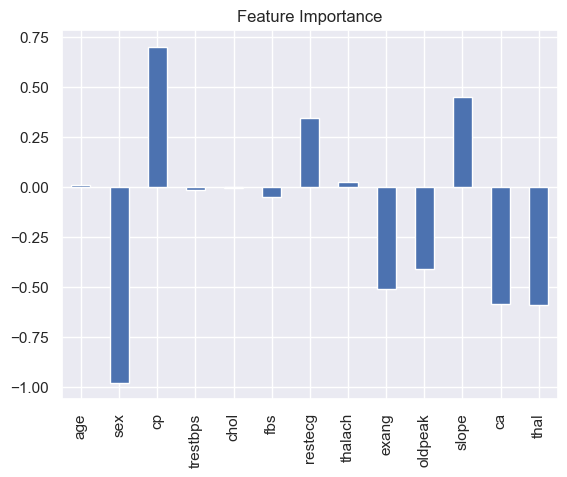

In [245]:
feature_df.T.plot.bar(title="Feature Importance", legend=False)
plt.show()